# Sprint 1 Baseline Outcome Prediction Pipeline

This notebook demonstrates the initial end-to-end pipeline for explainable process outcome prediction.

Current pipeline stages:
1. Event log loading
2. Outcome labeling
3. Feature encoding
4. Baseline model training
5. Basic evaluation

The current implementation is intended as a first vertical slice ("tracer bullet") and will be refined in later sprints.

## 1. Imports and Project Setup

This section imports the required modules and configures the notebook environment.

In [4]:
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [6]:
    from sklearn.model_selection import train_test_split

    from src.dataExtraction.extract import import_data
    from src.featureEngineering.outcome_labelling import compute_duration_outcomes, tempFormat
    from src.featureEngineering.feature_encoding import Encode
    from src.modeling.baseline import train_majority_baseline
    from src.modeling.evaluation import (compute_basic_metrics,compute_metrics_with_roc_auc, save_roc_curve, save_confusion_matrix_plot,)

## 2. Event Log Loading

The raw XES event log is loaded and minimally cleaned.
Unnecessary attributes are removed before further processing.

In [7]:
data_path = project_root / "data" / "raw" / "BPI_Challenge_2013_incidents" / "BPI_Challenge_2013_incidents.xes"

drop_columns = ["impact", "org:role"]

df = import_data(str(data_path), drop_columns=drop_columns)
df.head()

/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 7554/7554 [00:01<00:00, 6942.05it/s]


      org:group resource country organization country org:resource  \
0           V30           France                   fr     Frederic   
1           V30           France                   fr     Frederic   
2        V5 3rd           France                   fr     Frederic   
3        V5 3rd           France                   fr  Anne Claire   
4           V30           France                   fr  Anne Claire   
...         ...              ...                  ...          ...   
65528        C9           Brazil                   br      Lierson   
65529        C9           Brazil                   br      Lierson   
65530        C9           Brazil                   br      Lierson   
65531        C9           Brazil                   br      Lierson   
65532       N36              USA                   us         Matt   

      organization involved concept:name  product lifecycle:transition  \
0               Org line A2     Accepted  PROD582          In Progress   
1          

,org:group,resource country,organization country,org:resource,organization involved,concept:name,product,lifecycle:transition,time:timestamp,case:concept:name
0,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 16:59:42+00:00,1-364285768
1,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 17:00:56+00:00,1-364285768
2,V5 3rd,France,fr,Frederic,Org line A2,Queued,PROD582,Awaiting Assignment,2010-03-31 17:45:48+00:00,1-364285768
3,V5 3rd,France,fr,Anne Claire,Org line A2,Accepted,PROD582,In Progress,2010-04-06 16:44:07+00:00,1-364285768
4,V30,France,fr,Anne Claire,Org line A2,Queued,PROD582,Awaiting Assignment,2010-04-06 16:44:38+00:00,1-364285768


## 3. Outcome Definition and Labeling

A temporary binary outcome definition is used for Sprint 1.

Positive outcome:
- case duration <= median case duration

Negative outcome:
- case duration > median case duration

This definition is primarily intended to create a balanced binary classification task for initial pipeline testing.

In [8]:
from importlib import reload
import src.featureEngineering.outcome_labelling as outcomeLabelling

reload(outcomeLabelling)

case_outcomes = outcomeLabelling.compute_duration_outcomes(df)

case_outcomes.columns

Index(['case:concept:name', 'case_start', 'case_end', 'duration', 'outcome'], dtype='str')

In [9]:
case_outcomes = compute_duration_outcomes(df)

df_labeled = tempFormat(df, case_outcomes)

df_labeled[["case:concept:name", "concept:name", "outcome"]].head()

,case:concept:name,concept:name,outcome
0,1-364285768,Accepted,0
1,1-364285768,Accepted,0
2,1-364285768,Queued,0
3,1-364285768,Accepted,0
4,1-364285768,Queued,0


## 4. Feature Encoding

The event log is transformed into a case-level feature representation.

Current encoding:
- activity occurrence one-hot encoding
- aggregated numerical statistics

The current implementation ignores activity ordering and serves as a simple baseline feature representation.

In [11]:
X, y, case_ids = Encode(df_labeled)
X.shape, y.shape, len(case_ids)

((7554, 236), (7554,), 7554)

In [12]:
y.value_counts()

outcome
0    3777
1    3777
Name: count, dtype: int64

## 5. Baseline Model

A majority-class baseline classifier is trained using scikit-learn's `DummyClassifier`.

The baseline always predicts the most frequent class observed in the training data.

In [13]:
X_train, X_test, y_train, y_test, case_ids_train, case_ids_test = train_test_split(
    X,
    y,
    case_ids,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [14]:
baseline_model = train_majority_baseline(X_train, y_train)
baseline_model.classes_

array([0, 1])

In [15]:
y_pred = baseline_model.predict(X_test)
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [16]:
y_proba = baseline_model.predict_proba(X_test)[:, 1]
y_proba[:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## 6. Evaluation

The baseline model is evaluated using:
- accuracy
- precision
- recall
- F1 score

Current evaluation uses a simple stratified train/test split and will later be replaced with more process-aware evaluation strategies.

In [17]:
metrics = compute_basic_metrics(y_test, y_pred)
metrics

{'accuracy': 0.499669093315685,
 'f1': 0.6663724624889673,
 'precision': 0.499669093315685,
 'recall': 1.0}

### Baseline Evaluation Interpretation

The majority-class baseline achieves approximately 50% accuracy, which is expected due to the near-balanced outcome distribution created by the median-based labeling strategy.

The model predicts only the majority class, resulting in:
- perfect recall for the positive class,
- low precision,
- and moderate F1 score.

These results establish a minimal reference point for later predictive models.

In [18]:
from src.output.prediction_output import (
    save_prediction_output,
    create_sprint1_visualizations,
)

prediction_output = save_prediction_output(
    case_ids=case_ids_test,
    y_true=y_test,
    predictions=y_pred,
    probabilities=y_proba,
    model_name="majority_baseline",
    model_type="baseline",
    dataset_split="test",
    threshold=0.5,
    sprint="sprint2",
    output_path="reports/predictions_sprint2.csv",
)

saved_figures = create_sprint1_visualizations(
    prediction_output=prediction_output,
    figures_dir="figures",
)

prediction_output.head(), saved_figures

(       case_id  y_true  prediction  probability              model model_type  \
 0  1-740610271       1           1          1.0  majority_baseline   baseline   
 1  1-729748248       0           1          1.0  majority_baseline   baseline   
 2  1-740760140       1           1          1.0  majority_baseline   baseline   
 3  1-736499071       0           1          1.0  majority_baseline   baseline   
 4  1-738448756       1           1          1.0  majority_baseline   baseline   
 
   dataset_split  threshold   sprint  
 0          test        0.5  sprint2  
 1          test        0.5  sprint2  
 2          test        0.5  sprint2  
 3          test        0.5  sprint2  
 4          test        0.5  sprint2  ,
 {'prediction_distribution': PosixPath('figures/prediction_distribution_sprint2.png'),
  'label_distribution': PosixPath('figures/label_distribution_sprint2.png')})

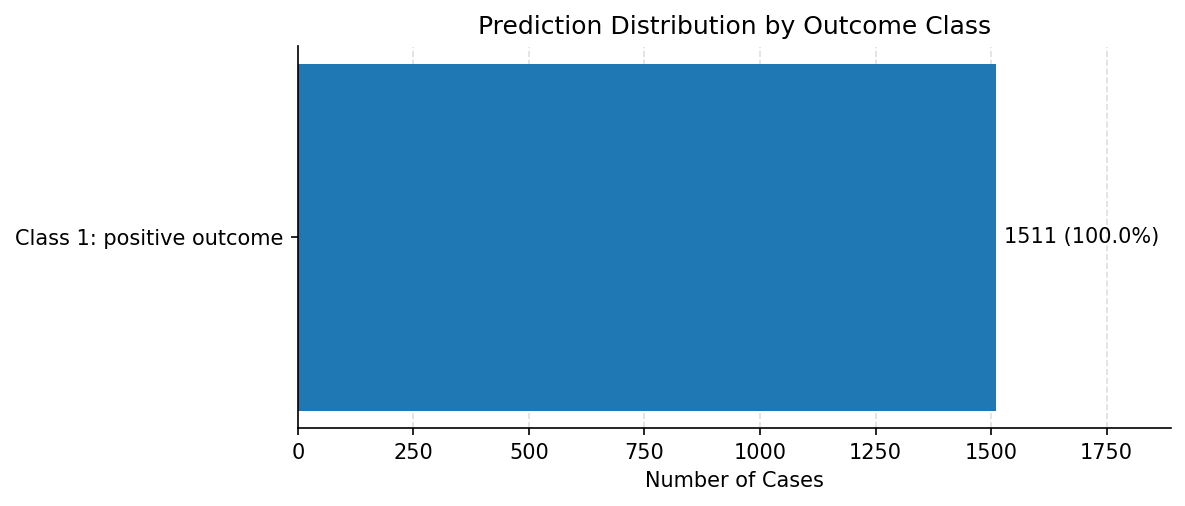

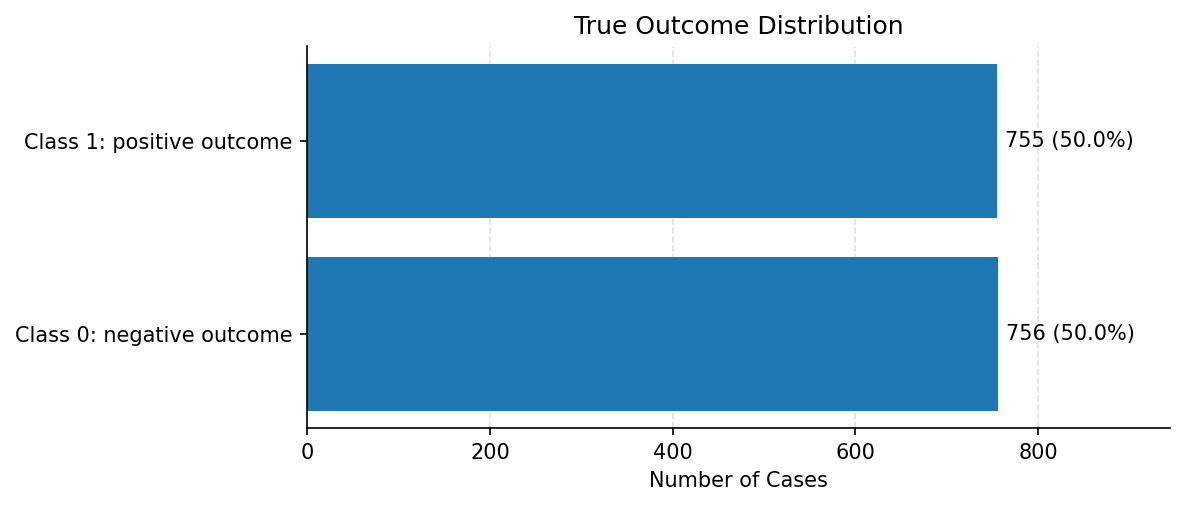

In [19]:
from IPython.display import Image, display

display(Image(filename="figures/prediction_distribution_sprint1.png"))
display(Image(filename="figures/label_distribution_sprint1.png"))

### ROC Curve and AUC Analysis

The ROC curve was added to evaluate how well the model separates the two outcome classes across different classification thresholds. The curve plots the **False Positive Rate** on the x-axis and the **True Positive Rate** on the y-axis.

For the current majority baseline model, the ROC curve is not very informative because the model predicts only one class for all test cases. As shown in the prediction distribution, all cases are predicted as **Class 1: positive outcome**, while the true outcome distribution contains both **Class 0: negative outcome** and **Class 1: positive outcome** in nearly equal proportions.

This means that the majority baseline does not distinguish between positive and negative cases. Therefore, the ROC curve mainly serves as a reference point for later models. More advanced models, such as Logistic Regression or Random Forest, are expected to produce more varied prediction probabilities, making the ROC curve and ROC AUC more meaningful for model comparison.

The ROC AUC score summarizes the model’s ability to rank positive cases higher than negative cases. A value close to `0.5` indicates performance similar to random guessing, while a value closer to `1.0` indicates better separation between the classes.

In [20]:
metrics = compute_basic_metrics(y_test, y_pred)
metrics

{'accuracy': 0.499669093315685,
 'f1': 0.6663724624889673,
 'precision': 0.499669093315685,
 'recall': 1.0}

In [21]:

metrics = compute_metrics_with_roc_auc(

    y_true=y_test,

    y_pred=y_pred,

    y_score=y_proba,

)
roc_curve_path = save_roc_curve(

    y_true=y_test,

    y_score=y_proba,

    model_name="majority_baseline",

    output_path="figures/roc_curve_sprint2.png",

)
metrics, roc_curve_path

({'accuracy': 0.499669093315685,
  'f1': 0.6663724624889673,
  'precision': 0.499669093315685,
  'recall': 1.0,
  'roc_auc': 0.5},
 PosixPath('figures/roc_curve_sprint2.png'))

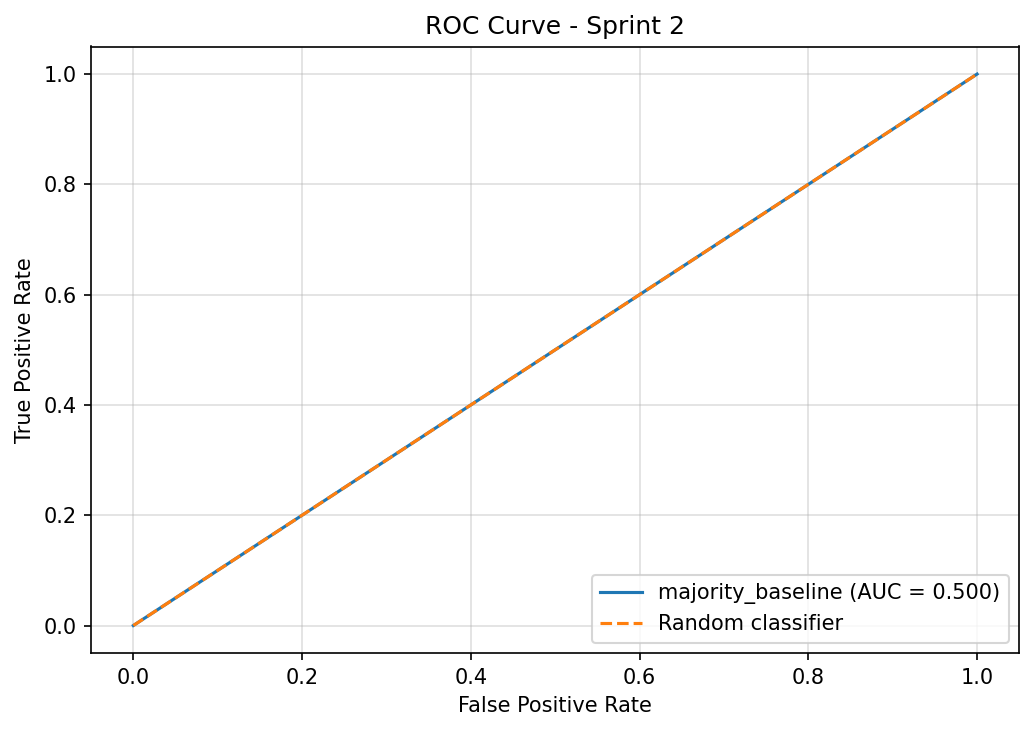

In [22]:
from IPython.display import Image, display
display(Image(filename="figures/roc_curve_sprint2.png"))

### Implementation of the Confusion Matrix

The confusion matrix was implemented as an additional evaluation visualization for Sprint 2. It compares the true outcome labels with the predicted labels of the model and shows how many cases were classified correctly or incorrectly.

For binary classification, the matrix distinguishes between:

The plot is generated from `y_test` and `y_pred` and saved as:

```text
figures/confusion_matrix_sprint2.png

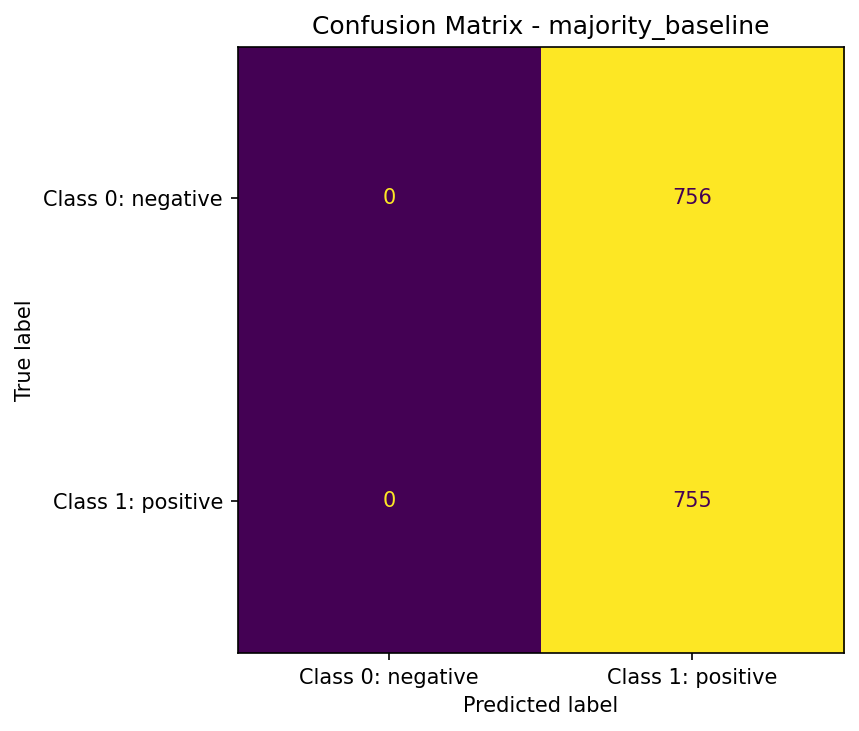

In [23]:
from IPython.display import Image, display
from src.modeling.evaluation import save_confusion_matrix_plot
confusion_matrix_path = save_confusion_matrix_plot(
    y_true=y_test,
    y_pred=y_pred,
    model_name="majority_baseline",
    output_path="figures/confusion_matrix_sprint2.png",
)

display(Image(filename=str(confusion_matrix_path)))

### Model Comparison Table and Plot

The model comparison table summarizes the evaluation metrics for the models included in the Sprint 2 pipeline. Each row represents one model, and the columns contain the main classification metrics, including accuracy, precision, recall, F1-score, and ROC AUC.

The comparison plot visualizes selected metrics from this table, such as F1-score and ROC AUC. This makes it easier to compare model performance visually instead of only reading the numeric values.

At the current stage, the table contains the majority baseline model. When additional Sprint 2 models, such as Logistic Regression or Random Forest, are implemented, their metrics can be added to the same results list and will automatically appear in the table and plot.

,model,accuracy,precision,recall,f1,roc_auc
0,majority_baseline,0.499669,0.499669,1.0,0.666372,0.5


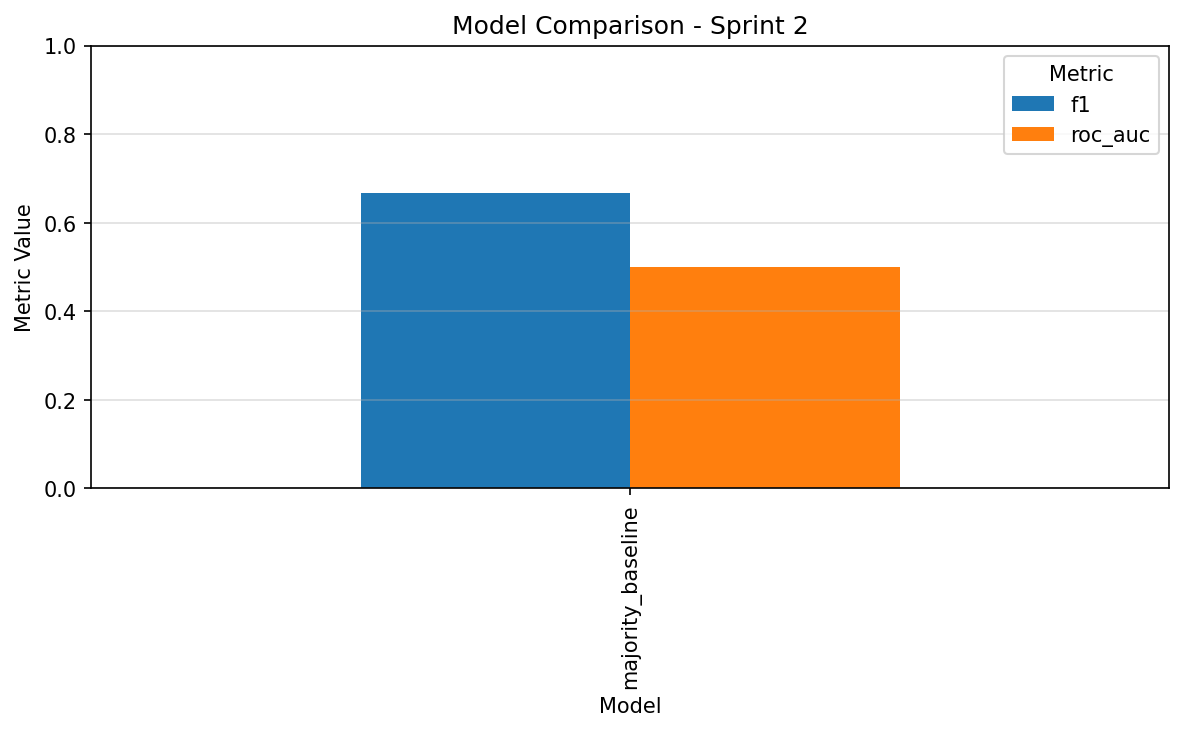

(PosixPath('reports/model_comparison_sprint2.csv'),
 PosixPath('figures/model_comparison_sprint2.png'))

In [24]:
from pathlib import Path
from IPython.display import Image, display
from src.modeling.evaluation import (
    build_evaluation_table,
    save_model_comparison_plot,
)

metrics_with_model = {
    "model": "majority_baseline",
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1": metrics["f1"],
    "roc_auc": metrics["roc_auc"],
}

results = [
    metrics_with_model,
]

evaluation_table = build_evaluation_table(results)

comparison_table_path = Path("reports/model_comparison_sprint2.csv")
comparison_table_path.parent.mkdir(parents=True, exist_ok=True)
evaluation_table.to_csv(comparison_table_path, index=False)

comparison_plot_path = save_model_comparison_plot(
    evaluation_table=evaluation_table,
    output_path="figures/model_comparison_sprint2.png",
)

display(evaluation_table)
display(Image(filename=str(comparison_plot_path)))

comparison_table_path, comparison_plot_path